# PPS reference validation bằng hệ Rössler

Notebook kiểm chứng PPS theo từng tầng độc lập dựa trên [Small et al. (2001)](https://doi.org/10.1103/PhysRevLett.87.188101): source data, distance scale, định nghĩa `C_n`, coarse/fine rho sweep, copied-run diagnostics, scalar geometry và correlation-dimension gate.

## Task 0 - Thiết lập môi trường và tham số

Các seed, initial condition, integrator và quy tắc bơm noise được cố định để kết quả tái lập được.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist, pdist


def find_project_root():
    """Locate the repository root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        pps_path = (
            candidate / "phase1" / "src" / "surrogates" / "pps.py"
        )
        if pps_path.exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy PPS core.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "phase1"))

from src.surrogates.pps import (
    consecutive_run_lengths,
    count_matching_segments,
    embed_phase_space,
    generate_pps_indices,
    summarize_pps_indices,
)

N_SAMPLES = 5_000
SAMPLE_STEP = 0.2
TRANSIENT_TIME = 200.0
NOISE_SIGMA = 0.05
INITIAL_STATE = np.array((1.0, 0.0, 0.0))
EMBEDDING_DIMENSION = 3
DELAY = 8
SEGMENT_LENGTHS = (2, 3, 4, 5)
COARSE_RHO = np.logspace(-10, 0, 41)
COARSE_TRIALS = 3
FINE_RHO = np.geomspace(0.03, 0.30, 31)
FINE_MASTER_SEEDS = 5
FINE_TRIALS = 20
N_SURROGATES = 30
ALPHA = 0.05

DATASET_CONFIGS = {
    "Chaos": {"a": 0.398, "seed": 600},
    "Period-6": {"a": 0.3909, "seed": 601},
}

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## Task 0.5 - Unit test định nghĩa Cn

Mặc định paper-aligned đếm maximal runs có `length >= n`. Chế độ `exact` được giữ riêng để audit ambiguity, không dùng làm criterion tối ưu.

In [2]:
toy_indices = [10, 11, 30, 31, 50, 51, 52, 90, 91]
np.testing.assert_array_equal(
    consecutive_run_lengths(toy_indices),
    np.array([2, 2, 3, 2]),
)
assert count_matching_segments(toy_indices, 2) == 4
assert count_matching_segments(toy_indices, 3) == 1
assert count_matching_segments(toy_indices, 2, mode="exact") == 3
assert count_matching_segments(np.arange(10), 2) == 1
assert count_matching_segments(np.arange(10), 10) == 1
assert count_matching_segments(np.arange(10), 2, mode="exact") == 0
assert count_matching_segments([10, 50, 100], 2) == 0
print("All maximal-run checks passed.")

All maximal-run checks passed.


## Task 1 - Reproduce clean và noisy Rössler

Hệ được tích phân bằng RK4 với mỗi bước bằng đúng sampling interval 0.2. Sau mỗi bước deterministic, Gaussian noise có SD 0.05 được cộng vào cả `x`, `y`, `z`, rồi state nhiễu tiếp tục được dùng ở bước sau. Đây là dynamic state noise, không phải output noise.

In [3]:
def rossler_drift(state, a):
    """Return the Rössler vector field."""
    x, y, z = state
    return np.array((-(y + z), x + a * y, 2.0 + z * (x - 4.0)))


def rk4_step(state, a, step):
    """Advance one deterministic RK4 step."""
    k1 = rossler_drift(state, a)
    k2 = rossler_drift(state + 0.5 * step * k1, a)
    k3 = rossler_drift(state + 0.5 * step * k2, a)
    k4 = rossler_drift(state + step * k3, a)
    return state + step * (k1 + 2 * k2 + 2 * k3 + k4) / 6


def simulate_rossler(a, noise_sigma, seed):
    """Simulate clean or dynamically noisy Rössler data."""
    rng = np.random.default_rng(seed)
    state = INITIAL_STATE.astype(float).copy()
    burn_steps = int(round(TRANSIENT_TIME / SAMPLE_STEP))
    trajectory = np.empty((N_SAMPLES, 3), dtype=float)

    for step_index in range(burn_steps + N_SAMPLES):
        state = rk4_step(state, a, SAMPLE_STEP)
        if noise_sigma > 0.0:
            state += rng.normal(0.0, noise_sigma, size=3)
        if step_index >= burn_steps:
            trajectory[step_index - burn_steps] = state

    return trajectory


datasets = {}
for name, config in DATASET_CONFIGS.items():
    clean = simulate_rossler(config["a"], 0.0, config["seed"])
    noisy = simulate_rossler(
        config["a"], NOISE_SIGMA, config["seed"]
    )
    datasets[name] = {
        "a": config["a"],
        "clean": clean,
        "noisy": noisy,
        "signal": noisy[:, 0],
    }

simulation_audit = pd.DataFrame(
    {
        name: {
            "a": data["a"],
            "clean_std_x": data["clean"][:, 0].std(),
            "noisy_std_x": data["signal"].std(),
            "state_rms_delta": np.sqrt(
                np.mean((data["noisy"] - data["clean"]) ** 2)
            ),
        }
        for name, data in datasets.items()
    }
).T
simulation_audit

,a,clean_std_x,noisy_std_x,state_rms_delta
Chaos,0.3980,2.305866,2.160803,2.164214
Period-6,0.3909,2.323375,2.232730,1.577990


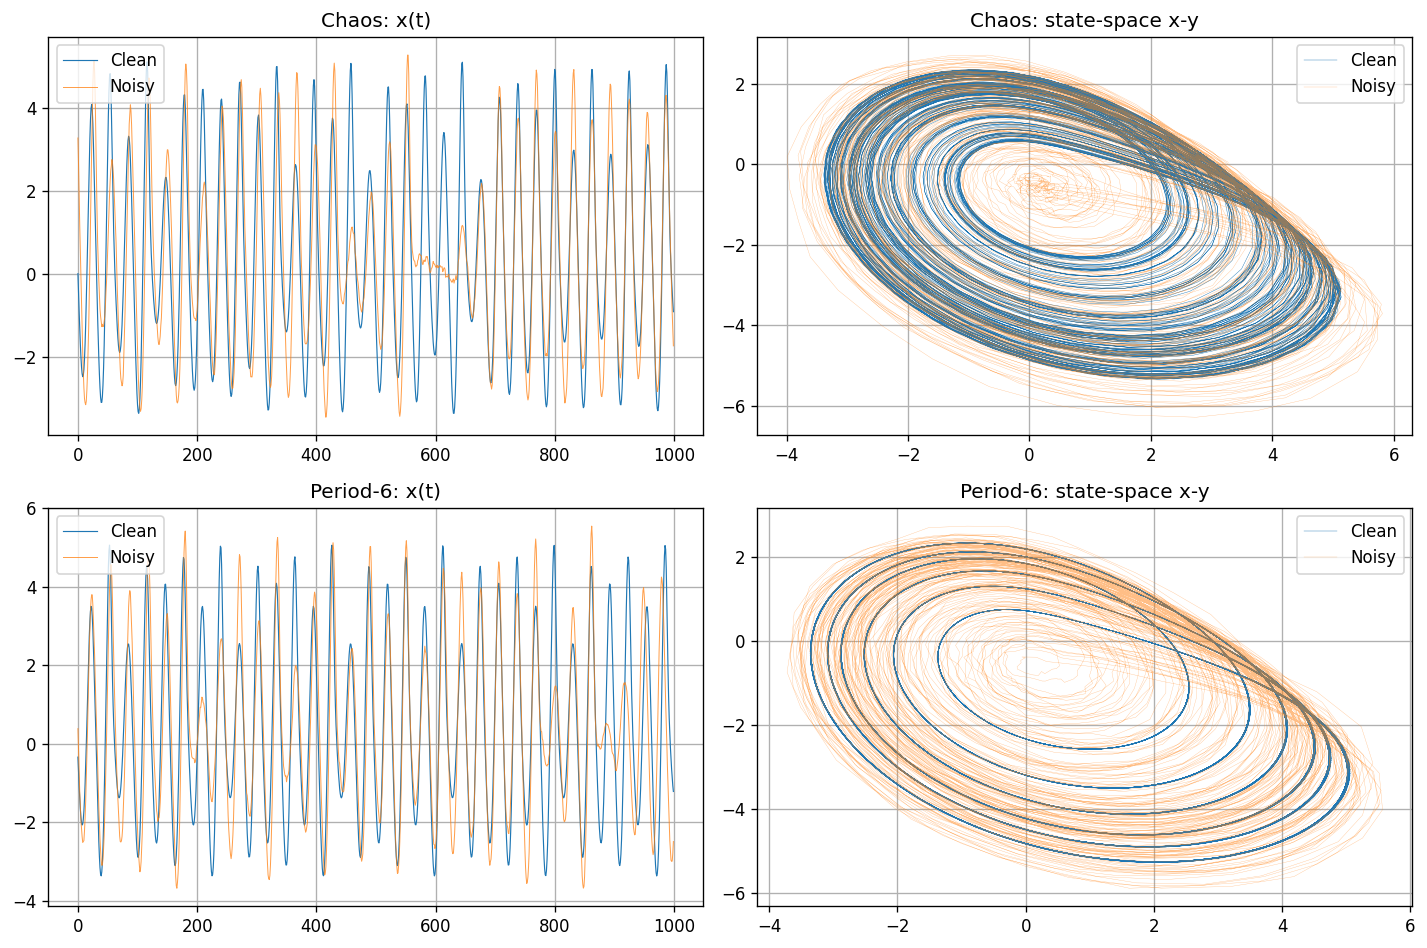

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (name, data) in enumerate(datasets.items()):
    axes[row, 0].plot(
        data["clean"][:1_000, 0],
        linewidth=0.7,
        label="Clean",
    )
    axes[row, 0].plot(
        data["noisy"][:1_000, 0],
        linewidth=0.6,
        alpha=0.75,
        label="Noisy",
    )
    axes[row, 0].set_title(f"{name}: x(t)")
    axes[row, 0].legend()
    axes[row, 1].plot(
        data["clean"][:, 0],
        data["clean"][:, 1],
        linewidth=0.25,
        label="Clean",
    )
    axes[row, 1].plot(
        data["noisy"][:, 0],
        data["noisy"][:, 1],
        linewidth=0.2,
        alpha=0.5,
        label="Noisy",
    )
    axes[row, 1].set_title(f"{name}: state-space x-y")
    axes[row, 1].legend()
fig.tight_layout()
plt.show()

## Task 2 - Audit embedding và distance scale

Nearest-neighbor và pairwise distances được đo trên embedding `(m=3, tau=8)`. `r` được báo cáo cả theo raw unit, median NN và attractor diameter.

In [5]:
distance_rows = []
for name, data in datasets.items():
    embedded = embed_phase_space(
        data["signal"], DELAY, EMBEDDING_DIMENSION
    )
    data["embedded"] = embedded
    nearest = cKDTree(embedded).query(embedded, k=2)[0][:, 1]
    pairwise = pdist(embedded)
    distance_rows.append(
        {
            "dataset": name,
            "std_x": data["signal"].std(),
            "range_x": np.ptp(data["signal"]),
            "nn_q05": np.quantile(nearest, 0.05),
            "nn_median": np.median(nearest),
            "nn_q95": np.quantile(nearest, 0.95),
            "pair_q05": np.quantile(pairwise, 0.05),
            "pair_median": np.median(pairwise),
            "pair_q95": np.quantile(pairwise, 0.95),
            "attractor_diameter": pairwise.max(),
        }
    )
    del pairwise

distance_summary = pd.DataFrame(distance_rows).set_index("dataset")
distance_summary

,std_x,range_x,nn_q05,nn_median,nn_q95,pair_q05,pair_median,pair_q95,attractor_diameter
dataset,,,,,,,,,
Chaos,2.160803,9.809838,0.045507,0.125721,0.247748,1.270284,4.634681,8.712055,12.162764
Period-6,2.232730,9.288053,0.050034,0.125171,0.232836,1.280182,4.896411,8.810228,11.854703


## Task 3 - Coarse rho sweep và so sánh hai định nghĩa Cn

Cả hai definitions được tính từ cùng PPS indices. `at_least` tương ứng các nested curves “more than n successive points” của Fig. 2; `exact` chỉ là diagnostic đối chứng.

In [6]:
def coarse_rho_sweep(signal, embedded, seed):
    """Evaluate exact and threshold run counts."""
    shape = (len(SEGMENT_LENGTHS), len(COARSE_RHO), COARSE_TRIALS)
    counts = {
        "at_least": np.empty(shape),
        "exact": np.empty(shape),
    }
    child_seeds = iter(
        np.random.SeedSequence(seed).spawn(
            len(COARSE_RHO) * COARSE_TRIALS
        )
    )
    for rho_index, rho in enumerate(COARSE_RHO):
        for trial in range(COARSE_TRIALS):
            indices = generate_pps_indices(
                embedded,
                rho,
                len(signal),
                np.random.default_rng(next(child_seeds)),
            )
            for length_index, segment_length in enumerate(
                SEGMENT_LENGTHS
            ):
                for mode in counts:
                    counts[mode][length_index, rho_index, trial] = (
                        count_matching_segments(
                            indices, segment_length, mode=mode
                        )
                    )
    return {
        mode: {
            "mean": values.mean(axis=2),
            "std": values.std(axis=2, ddof=1),
        }
        for mode, values in counts.items()
    }


coarse_results = {}
for dataset_index, (name, data) in enumerate(datasets.items()):
    coarse_results[name] = coarse_rho_sweep(
        data["signal"],
        data["embedded"],
        2_000 + dataset_index,
    )

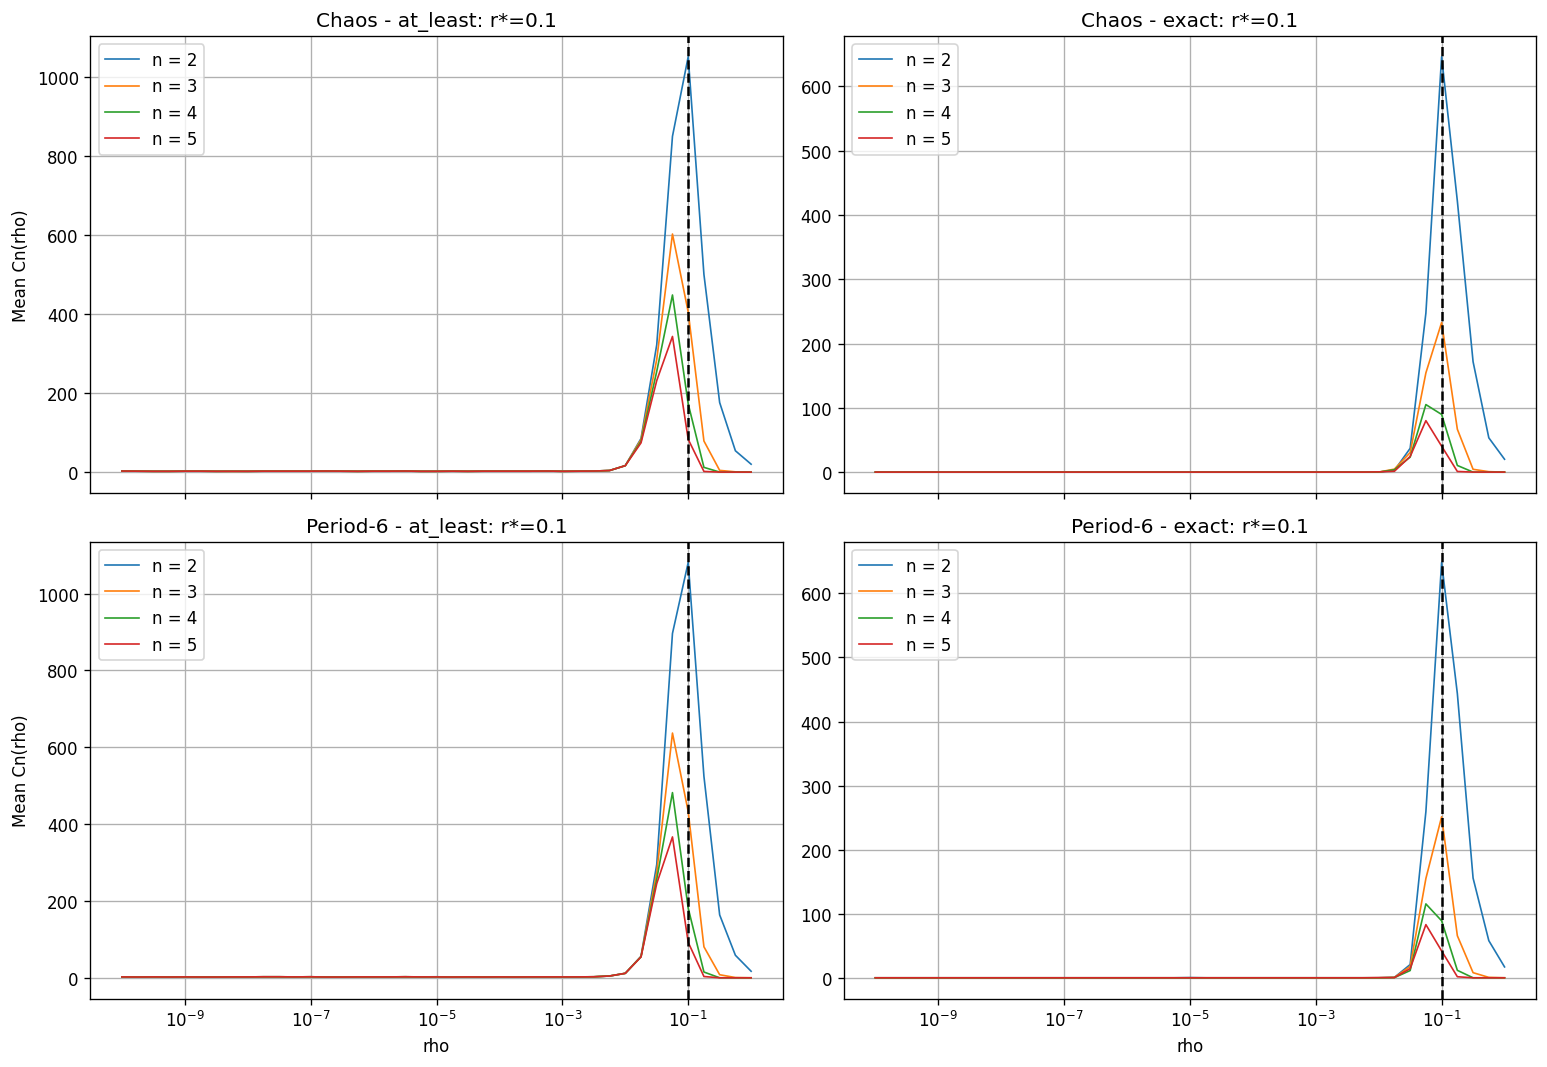

,coarse_rho,c2_small,c2_peak,c2_large,curves_nested
dataset,,,,,
Chaos,0.1,2.666667,1051.333333,20.0,True
Period-6,0.1,2.333333,1081.000000,17.0,True


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
coarse_rows = []
for row, (name, result) in enumerate(coarse_results.items()):
    for column, mode in enumerate(("at_least", "exact")):
        axis = axes[row, column]
        means = result[mode]["mean"]
        for length_index, segment_length in enumerate(
            SEGMENT_LENGTHS
        ):
            axis.semilogx(
                COARSE_RHO,
                means[length_index],
                linewidth=1.0,
                label=f"n = {segment_length}",
            )
        best_index = int(np.argmax(means[0]))
        axis.axvline(
            COARSE_RHO[best_index],
            color="black",
            linestyle="--",
        )
        axis.set_title(
            f"{name} - {mode}: r*={COARSE_RHO[best_index]:.3g}"
        )
        axis.legend()
        if mode == "at_least":
            coarse_rows.append(
                {
                    "dataset": name,
                    "coarse_rho": COARSE_RHO[best_index],
                    "c2_small": means[0, 0],
                    "c2_peak": means[0, best_index],
                    "c2_large": means[0, -1],
                    "curves_nested": bool(
                        np.all(np.diff(means, axis=0) <= 0)
                    ),
                }
            )
for axis in axes[-1]:
    axis.set_xlabel("rho")
for axis in axes[:, 0]:
    axis.set_ylabel("Mean Cn(rho)")
fig.tight_layout()
plt.show()

coarse_summary = pd.DataFrame(coarse_rows).set_index("dataset")
coarse_summary

## Task 4 - Fine rho sweep và seed robustness

Fine sweep dùng full transition CDF trên toàn bộ candidate set. Sampler batch chỉ cache cùng phân phối để chạy 5 master seed × 20 trial; không thêm cutoff, self-exclusion hoặc nearest-neighbor approximation.

In [8]:
def rowwise_search(cdf, rows, probabilities):
    """Search one CDF row per trajectory."""
    lower = np.zeros(len(rows), dtype=np.int32)
    upper = np.full(len(rows), cdf.shape[1], dtype=np.int32)
    while np.any(lower < upper):
        middle = (lower + upper) // 2
        active = lower < upper
        probe = np.minimum(middle, cdf.shape[1] - 1)
        move_right = active & (cdf[rows, probe] < probabilities)
        upper = np.where(active & ~move_right, middle, upper)
        lower = np.where(move_right, middle + 1, lower)
    return lower


def sample_pps_batch(cdf, length, size, seed, return_indices=False):
    """Sample multiple PPS paths from one transition CDF."""
    rng = np.random.default_rng(seed)
    current = rng.integers(0, cdf.shape[0], size=size)
    run_length = np.ones(size, dtype=np.int32)
    thresholds = np.asarray(SEGMENT_LENGTHS)
    counts = np.zeros((size, len(thresholds)), dtype=np.int32)
    indices = (
        np.empty((size, length), dtype=np.int32)
        if return_indices
        else None
    )
    if indices is not None:
        indices[:, 0] = current

    for step in range(1, length):
        chosen = rowwise_search(cdf, current, rng.random(size))
        successor = chosen + 1
        consecutive = successor == current + 1
        broken = ~consecutive
        if np.any(broken):
            counts[broken] += (
                run_length[broken, None] >= thresholds
            )
        run_length = np.where(consecutive, run_length + 1, 1)
        current = successor
        if indices is not None:
            indices[:, step] = current

    counts += run_length[:, None] >= thresholds
    return counts, indices


def transition_cdf(distances, rho):
    """Build the exact full-candidate transition CDF."""
    cdf = np.exp(-distances / rho)
    np.cumsum(cdf, axis=1, out=cdf)
    cdf /= cdf[:, -1, None]
    return cdf

In [9]:
fine_results = {}
pps_ensembles = {}
for dataset_index, (name, data) in enumerate(datasets.items()):
    embedded = data["embedded"]
    distances = cdist(embedded, embedded[:-1])
    distances -= distances.min(axis=1, keepdims=True)
    seed_means = np.empty((FINE_MASTER_SEEDS, len(FINE_RHO)))
    pooled_means = np.empty(len(FINE_RHO))
    pooled_stds = np.empty(len(FINE_RHO))

    for rho_index, rho in enumerate(FINE_RHO):
        cdf = transition_cdf(distances, rho)
        rho_counts = []
        for master_seed in range(FINE_MASTER_SEEDS):
            counts, _ = sample_pps_batch(
                cdf,
                N_SAMPLES,
                FINE_TRIALS,
                7_000 + 100 * dataset_index + master_seed,
            )
            seed_means[master_seed, rho_index] = (
                counts[:, 0].mean()
            )
            rho_counts.append(counts[:, 0])
        rho_counts = np.concatenate(rho_counts)
        pooled_means[rho_index] = rho_counts.mean()
        pooled_stds[rho_index] = rho_counts.std(ddof=1)
        del cdf

    best_index = int(np.argmax(pooled_means))
    best_rho = float(FINE_RHO[best_index])
    seed_rho = FINE_RHO[np.argmax(seed_means, axis=1)]
    fine_results[name] = {
        "rho": best_rho,
        "mean": pooled_means,
        "std": pooled_stds,
        "seed_rho": seed_rho,
        "seed_means": seed_means,
    }

    cdf = transition_cdf(distances, best_rho)
    _, indices = sample_pps_batch(
        cdf,
        N_SAMPLES,
        N_SURROGATES,
        10_000 + dataset_index,
        return_indices=True,
    )
    pps_ensembles[name] = {
        "indices": indices,
        "signals": embedded[indices, 0],
    }
    del cdf, distances

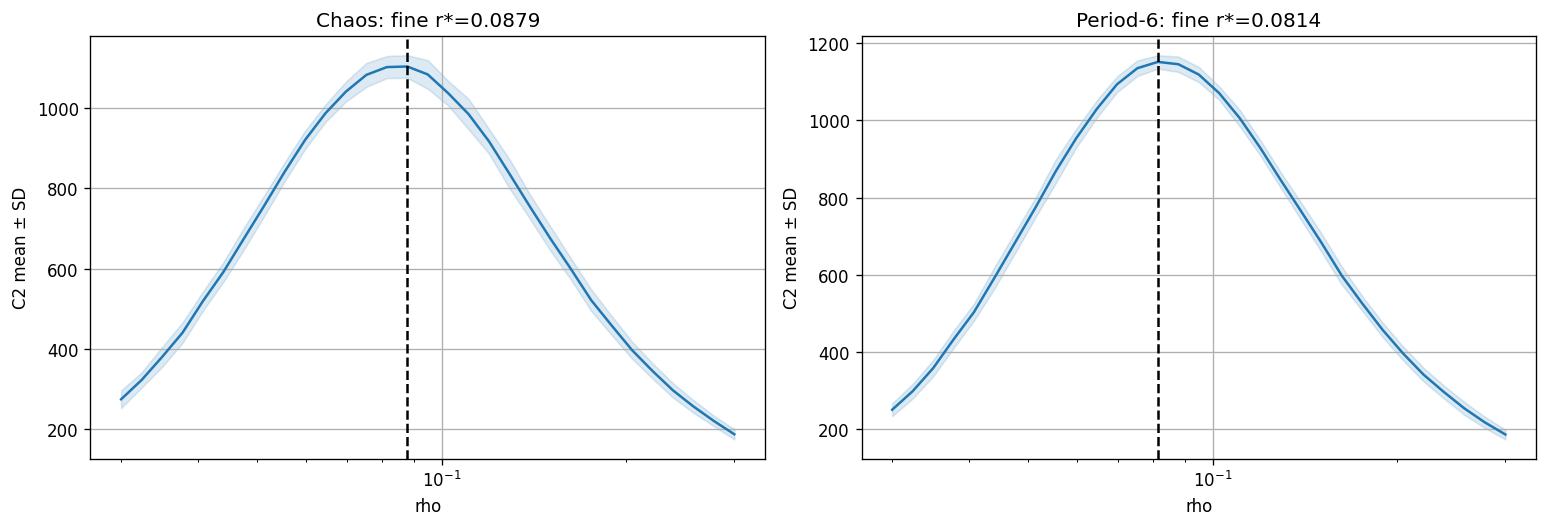

,rho_raw,rho_zscore,rho_over_nn,rho_over_diameter,c2_mean,c2_sd,seed_rho_min,seed_rho_max
dataset,,,,,,,,
Chaos,0.087859,0.040661,0.698845,0.007224,1103.46,28.116791,0.081368,0.087859
Period-6,0.081368,0.036443,0.650054,0.006864,1151.15,17.304974,0.081368,0.087859


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fine_rows = []
for axis, (name, result) in zip(axes, fine_results.items()):
    axis.plot(FINE_RHO, result["mean"], color="tab:blue")
    axis.fill_between(
        FINE_RHO,
        result["mean"] - result["std"],
        result["mean"] + result["std"],
        color="tab:blue",
        alpha=0.15,
    )
    axis.axvline(
        result["rho"], color="black", linestyle="--"
    )
    axis.set_xscale("log")
    axis.set_title(f"{name}: fine r*={result['rho']:.4f}")
    axis.set_xlabel("rho")
    axis.set_ylabel("C2 mean ± SD")

    scale = distance_summary.loc[name]
    signal_std = datasets[name]["signal"].std()
    best_index = int(np.argmax(result["mean"]))
    fine_rows.append(
        {
            "dataset": name,
            "rho_raw": result["rho"],
            "rho_zscore": result["rho"] / signal_std,
            "rho_over_nn": (
                result["rho"] / scale["nn_median"]
            ),
            "rho_over_diameter": (
                result["rho"] / scale["attractor_diameter"]
            ),
            "c2_mean": result["mean"][best_index],
            "c2_sd": result["std"][best_index],
            "seed_rho_min": result["seed_rho"].min(),
            "seed_rho_max": result["seed_rho"].max(),
        }
    )
fig.tight_layout()
plt.show()

fine_summary = pd.DataFrame(fine_rows).set_index("dataset")
fine_summary

## Task 5 - Temporal randomization và scalar PPS geometry

Mọi geometry metric được tính bằng cách embedding lại scalar PPS. Copied-run metrics dùng chính indices đã sinh ra signal.

In [11]:
def backward_embedding(signal):
    """Return backward-lag coordinates."""
    embedded = embed_phase_space(
        signal, DELAY, EMBEDDING_DIMENSION
    )
    return embedded[:, ::-1]


def dominant_frequency(signal):
    """Return the strongest nonzero Fourier frequency."""
    centered = signal - signal.mean()
    power = np.abs(np.fft.rfft(centered)) ** 2
    frequencies = np.fft.rfftfreq(len(centered), d=SAMPLE_STEP)
    return frequencies[1 + np.argmax(power[1:])]


quality_rows = []
for name, ensemble in pps_ensembles.items():
    original = datasets[name]["signal"]
    original_z = backward_embedding(original)
    original_tree = cKDTree(original_z)
    geometry_errors = []
    run_summaries = []
    for indices, surrogate in zip(
        ensemble["indices"], ensemble["signals"]
    ):
        surrogate_z = backward_embedding(surrogate)
        distances, _ = original_tree.query(surrogate_z, k=1)
        scale = np.linalg.norm(np.ptp(original_z, axis=0))
        geometry_errors.append(np.median(distances) / scale)
        run_summaries.append(summarize_pps_indices(indices))

    quality_rows.append(
        {
            "dataset": name,
            "variance_ratio": (
                np.var(ensemble["signals"], axis=1).mean()
                / np.var(original)
            ),
            "range_ratio": (
                np.ptp(ensemble["signals"], axis=1).mean()
                / np.ptp(original)
            ),
            "frequency_ratio": (
                np.mean(
                    [
                        dominant_frequency(signal)
                        for signal in ensemble["signals"]
                    ]
                )
                / dominant_frequency(original)
            ),
            "geometry_error": np.mean(geometry_errors),
            "successor_fraction": np.mean(
                [item["successor_fraction"] for item in run_summaries]
            ),
            "mean_run_length": np.mean(
                [item["mean_run_length"] for item in run_summaries]
            ),
            "max_run_length_mean": np.mean(
                [item["max_run_length"] for item in run_summaries]
            ),
        }
    )

quality_summary = pd.DataFrame(quality_rows).set_index("dataset")
quality_summary

,variance_ratio,range_ratio,frequency_ratio,geometry_error,successor_fraction,mean_run_length,max_run_length_mean
dataset,,,,,,,
Chaos,0.982354,0.989813,0.993827,0.008306,0.457451,1.844065,20.400000
Period-6,1.029124,0.992899,0.997930,0.008384,0.506228,2.025719,17.333333


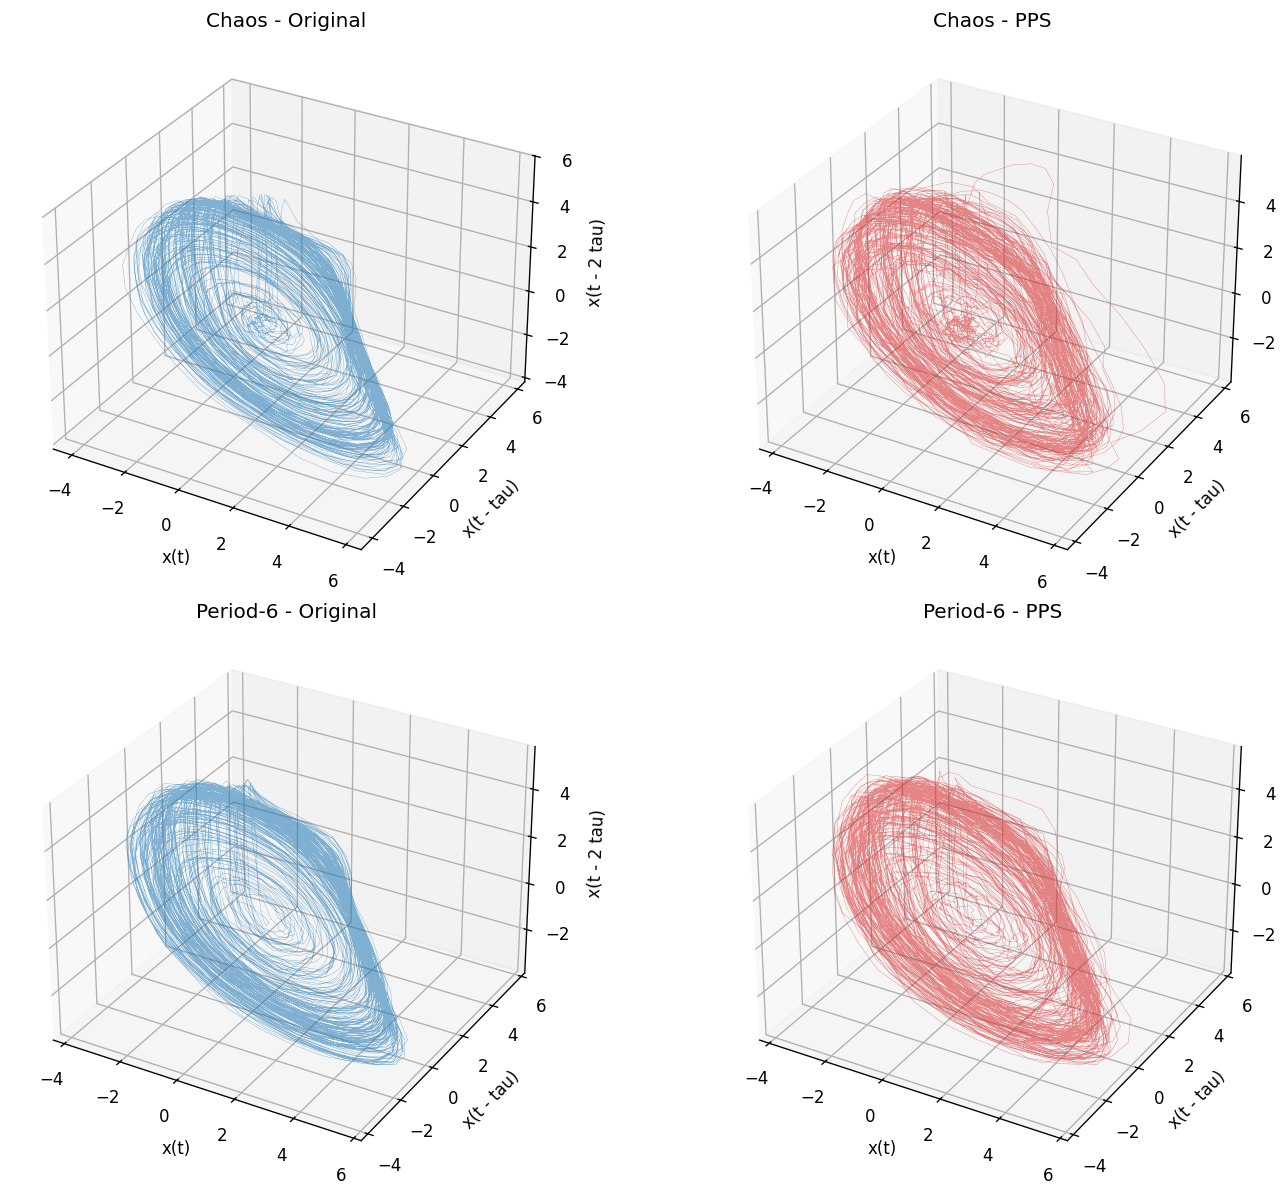

In [12]:
fig = plt.figure(figsize=(13, 10))
for row, name in enumerate(datasets):
    original_z = backward_embedding(datasets[name]["signal"])
    surrogate_z = backward_embedding(pps_ensembles[name]["signals"][0])
    for column, (label, embedded, color) in enumerate(
        (
            ("Original", original_z, "tab:blue"),
            ("PPS", surrogate_z, "tab:red"),
        )
    ):
        axis = fig.add_subplot(
            2, 2, row * 2 + column + 1, projection="3d"
        )
        axis.plot(
            embedded[:, 0],
            embedded[:, 1],
            embedded[:, 2],
            linewidth=0.25,
            alpha=0.55,
            color=color,
        )
        axis.set_title(f"{name} - {label}")
        axis.set_xlabel("x(t)")
        axis.set_ylabel("x(t - tau)")
        axis.set_zlabel("x(t - 2 tau)")
fig.tight_layout()
plt.show()

## Task 6 - Validate correlation-dimension estimator độc lập

Estimator Grassberger–Procaccia local-slope hiện tại được chạy trước trên clean/noisy data. Nếu noisy chaos và noisy period-6 đều bị chi phối bởi dimension của noise ở small scales, kết quả PPS null-test không được dùng để sửa transition core.

In [13]:
LOG_EPSILON = np.linspace(-3.5, 0.0, 36)
TEST_BAND = (LOG_EPSILON >= -2.5) & (LOG_EPSILON <= -1.5)
THEILER_WINDOW = 80
DIMENSION_MAX_POINTS = 2_500


def local_slopes(x, y, half_window=2):
    """Estimate local slopes with short regressions."""
    slopes = np.full(len(x), np.nan)
    for index in range(len(x)):
        start = max(0, index - half_window)
        stop = min(len(x), index + half_window + 1)
        valid = np.isfinite(y[start:stop])
        if valid.sum() >= 3:
            slopes[index] = np.polyfit(
                x[start:stop][valid],
                y[start:stop][valid],
                1,
            )[0]
    return slopes


def correlation_dimension_curve(signal):
    """Estimate a GP dimension curve across scales."""
    embedded = backward_embedding(signal)[:DIMENSION_MAX_POINTS]
    epsilon = np.exp(LOG_EPSILON)
    pairs = cKDTree(embedded).query_pairs(
        epsilon.max(), output_type="ndarray"
    )
    pairs = pairs[
        (pairs[:, 1] - pairs[:, 0]) > THEILER_WINDOW
    ]
    distances = np.linalg.norm(
        embedded[pairs[:, 0]] - embedded[pairs[:, 1]], axis=1
    )
    distances.sort()
    pair_counts = np.searchsorted(distances, epsilon, side="right")
    n_points = len(embedded)
    eligible_pairs = (
        (n_points - THEILER_WINDOW - 1)
        * (n_points - THEILER_WINDOW)
        / 2
    )
    log_correlation = np.full(len(epsilon), np.nan)
    valid = pair_counts >= 20
    log_correlation[valid] = np.log(
        pair_counts[valid] / eligible_pairs
    )
    return local_slopes(LOG_EPSILON, log_correlation)


def finite_column_summary(curves):
    """Return column means and percentile bounds safely."""
    means = np.full(curves.shape[1], np.nan)
    lower = np.full(curves.shape[1], np.nan)
    upper = np.full(curves.shape[1], np.nan)
    for index in range(curves.shape[1]):
        values = curves[:, index]
        values = values[np.isfinite(values)]
        if len(values):
            means[index] = values.mean()
            lower[index], upper[index] = np.percentile(
                values, (2.5, 97.5)
            )
    return means, lower, upper

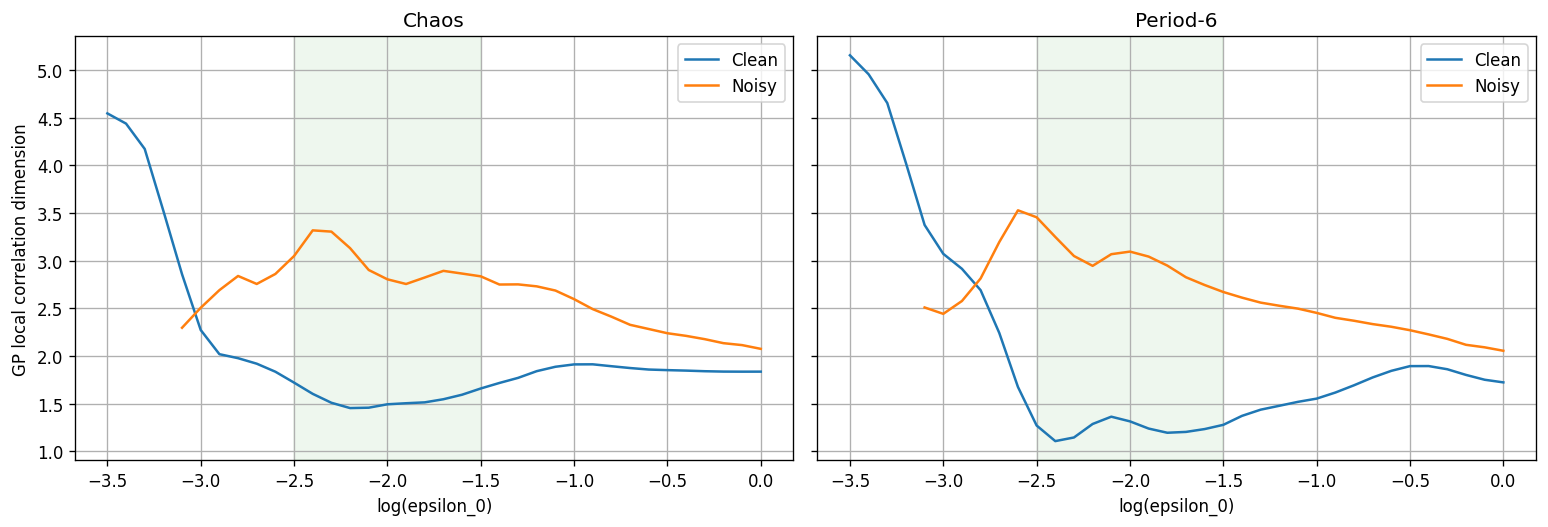

,clean_small_scale_dc,noisy_small_scale_dc
dataset,,
Chaos,1.551986,2.972345
Period-6,1.241218,3.010001


In [14]:
dimension_audit = {}
audit_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for axis, (name, data) in zip(axes, datasets.items()):
    clean_curve = correlation_dimension_curve(data["clean"][:, 0])
    noisy_curve = correlation_dimension_curve(data["signal"])
    dimension_audit[name] = {
        "clean": clean_curve,
        "noisy": noisy_curve,
    }
    axis.plot(LOG_EPSILON, clean_curve, label="Clean")
    axis.plot(LOG_EPSILON, noisy_curve, label="Noisy")
    axis.axvspan(-2.5, -1.5, color="tab:green", alpha=0.08)
    axis.set_title(name)
    axis.set_xlabel("log(epsilon_0)")
    axis.legend()
    audit_rows.append(
        {
            "dataset": name,
            "clean_small_scale_dc": np.nanmean(
                clean_curve[TEST_BAND]
            ),
            "noisy_small_scale_dc": np.nanmean(
                noisy_curve[TEST_BAND]
            ),
        }
    )
axes[0].set_ylabel("GP local correlation dimension")
fig.tight_layout()
plt.show()

dimension_audit_summary = pd.DataFrame(audit_rows).set_index("dataset")
dimension_audit_summary

## Task 7 - PPS null discrimination

Kết quả được ghi nhận nhưng chỉ được xem là kết luận về core nếu estimator gate ở Task 6 đạt.

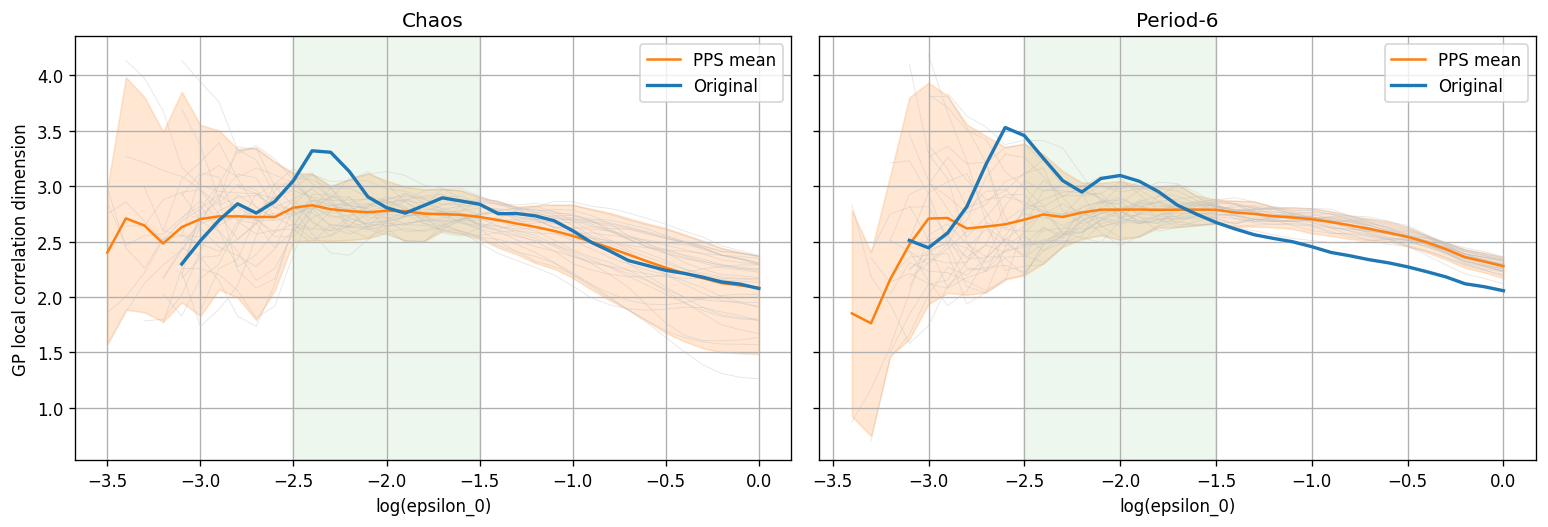

,original_statistic,surrogate_mean,p_value,decision
dataset,,,,
Chaos,2.972345,2.770863,1.0,Fail to reject H0
Period-6,3.010001,2.767284,1.0,Fail to reject H0


In [15]:
null_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for axis, name in zip(axes, datasets):
    original_curve = dimension_audit[name]["noisy"]
    surrogate_curves = np.vstack(
        [
            correlation_dimension_curve(signal)
            for signal in pps_ensembles[name]["signals"]
        ]
    )
    mean_curve, lower, upper = finite_column_summary(
        surrogate_curves
    )
    for curve in surrogate_curves:
        axis.plot(
            LOG_EPSILON,
            curve,
            color="0.75",
            linewidth=0.5,
            alpha=0.4,
        )
    axis.fill_between(
        LOG_EPSILON, lower, upper, color="tab:orange", alpha=0.18
    )
    axis.plot(
        LOG_EPSILON, mean_curve, color="tab:orange", label="PPS mean"
    )
    axis.plot(
        LOG_EPSILON,
        original_curve,
        color="tab:blue",
        linewidth=2.0,
        label="Original",
    )
    axis.axvspan(-2.5, -1.5, color="tab:green", alpha=0.08)
    axis.set_title(name)
    axis.set_xlabel("log(epsilon_0)")
    axis.legend()

    original_statistic = np.nanmean(original_curve[TEST_BAND])
    surrogate_statistics = np.nanmean(
        surrogate_curves[:, TEST_BAND], axis=1
    )
    p_value = (
        1
        + np.count_nonzero(
            surrogate_statistics <= original_statistic
        )
    ) / (N_SURROGATES + 1)
    null_rows.append(
        {
            "dataset": name,
            "original_statistic": original_statistic,
            "surrogate_mean": surrogate_statistics.mean(),
            "p_value": p_value,
            "decision": (
                "Reject H0"
                if p_value <= ALPHA
                else "Fail to reject H0"
            ),
        }
    )
axes[0].set_ylabel("GP local correlation dimension")
fig.tight_layout()
plt.show()

null_summary = pd.DataFrame(null_rows).set_index("dataset")
null_summary

## Task 8 - Stage-gated validation summary

`overall_pass` chỉ true khi simulation, rho behavior, seed stability, scale, temporal/geometry preservation, estimator và null decision cùng đạt.

In [16]:
validation_rows = []
expected_decisions = {
    "Chaos": "Reject H0",
    "Period-6": "Fail to reject H0",
}
estimator_pass = bool(
    dimension_audit_summary.loc["Chaos", "noisy_small_scale_dc"]
    < dimension_audit_summary.loc["Period-6", "noisy_small_scale_dc"]
    - 0.2
)

for name in datasets:
    coarse = coarse_summary.loc[name]
    fine = fine_summary.loc[name]
    quality = quality_summary.loc[name]
    rho_shape_pass = bool(
        coarse["c2_peak"] > coarse["c2_small"]
        and coarse["c2_peak"] > coarse["c2_large"]
        and coarse["curves_nested"]
    )
    seed_stability_pass = bool(
        fine["seed_rho_max"] / fine["seed_rho_min"] < 1.15
    )
    relative_scale_pass = bool(
        0.003 <= fine["rho_over_diameter"] <= 0.01
    )
    temporal_pass = bool(
        0.2 < quality["successor_fraction"] < 0.8
        and quality["mean_run_length"] < 3.0
    )
    geometry_pass = bool(
        quality["geometry_error"] < 0.05
        and 0.9 < quality["variance_ratio"] < 1.1
        and 0.9 < quality["frequency_ratio"] < 1.1
    )
    null_pass = bool(
        null_summary.loc[name, "decision"]
        == expected_decisions[name]
    )
    overall_pass = all(
        (
            rho_shape_pass,
            seed_stability_pass,
            relative_scale_pass,
            temporal_pass,
            geometry_pass,
            estimator_pass,
            null_pass,
        )
    )
    validation_rows.append(
        {
            "dataset": name,
            "rho_shape_pass": rho_shape_pass,
            "seed_stability_pass": seed_stability_pass,
            "relative_scale_pass": relative_scale_pass,
            "temporal_pass": temporal_pass,
            "geometry_pass": geometry_pass,
            "estimator_pass": estimator_pass,
            "null_pass": null_pass,
            "overall_pass": overall_pass,
        }
    )

validation_summary = pd.DataFrame(validation_rows).set_index("dataset")
validation_summary

,rho_shape_pass,seed_stability_pass,relative_scale_pass,temporal_pass,geometry_pass,estimator_pass,null_pass,overall_pass
dataset,,,,,,,,
Chaos,True,True,True,True,True,False,False,False
Period-6,True,True,True,True,True,False,True,False


## Báo cáo kết quả và đánh giá

### 1. Kết quả đã đạt được

- Mô phỏng Rössler dùng RK4, bước lấy mẫu `0.2`, `N = 5000` và 
noise động lực học `sigma = 0.05` trên cả ba biến trạng thái. Độ lệch 
RMS clean-noisy là `2.1642` cho Chaos và `1.5780` cho Period-6, xác 
nhận noise không chỉ được cộng vào tín hiệu quan sát.
- Embedding `m = 3`, `tau = 8` cho median nearest-neighbor lần lượt 
là `0.1257` và `0.1252`; đường kính attractor là `12.1628` và 
`11.8547`. Các đại lượng này được dùng để diễn giải rho theo scale 
hình học thay vì chỉ so giá trị tuyệt đối.
- Các toy test cho maximal consecutive runs đều đạt. Định nghĩa 
`exact` được giữ làm diagnostic; định nghĩa mặc định `at_least` tạo 
các đường `C2, C3, C4, C5` lồng nhau và tái hiện đúng peak trung gian.
- Coarse sweep cho peak tại `rho = 0.1`. Với Chaos, `C2` đi từ 
`2.67` lên `1051.33` rồi giảm còn `20.00`; với Period-6, các giá 
trị tương ứng là `2.33`, `1081.00` và `17.00`. Peak không nằm ở 
biên của toàn miền quét.
- Fine sweep 5 master seeds và 20 trial mỗi rho cho kết quả ổn định:

| Hệ | rho raw | rho z-score | rho/NN median | rho/diameter | 
mean C2 ± SD |
|---|---:|---:|---:|---:|---:|
| Chaos | 0.087859 | 0.040661 | 0.698845 | 0.007224 | 
1103.46 ± 28.12 |
| Period-6 | 0.081368 | 0.036443 | 0.650054 | 0.006864 | 
1151.15 ± 17.30 |

Khoảng rho tối ưu giữa các seed chỉ từ `0.081368` đến `0.087859`. 
Rho raw khác giá trị tuyệt đối trong paper, nhưng rho/diameter nằm gần 
`0.7%`; do đó discrepancy chủ yếu liên quan đến unit/scale và chưa phải 
bằng chứng sai transition kernel.

- Scalar PPS sau khi embedding lại giữ được coarse geometry:

| Hệ | Variance ratio | Range ratio | Frequency ratio | Geometry error | 
Successor fraction | Mean run | Mean max run |
|---|---:|---:|---:|---:|---:|---:|---:|
| Chaos | 0.9824 | 0.9898 | 0.9938 | 0.00831 | 0.4575 | 1.8441 | 
20.40 |
| Period-6 | 1.0291 | 0.9929 | 0.9979 | 0.00838 | 0.5062 | 
2.0257 | 17.33 |

Các tỷ lệ gần 1, geometry error dưới 1% và mean copied-run gần 2 cho 
thấy surrogate vừa bảo toàn attractor thô vừa phá vỡ đủ nhiều liên kết 
thời gian; không có dấu hiệu collapse hoặc copy toàn bộ quỹ đạo.

### 2. Gate chưa đạt

Estimator correlation dimension hiện tại không qua kiểm chứng độc lập. 
Ở small scale, clean Chaos/Period-6 cho `1.5520/1.2412`, nhưng hai 
chuỗi noisy cùng tăng lên `2.9723/3.0100`, gần như không còn khả năng 
phân biệt. Vì gate này thất bại, kết quả null test không được dùng để 
đánh giá ngược PPS generator.

Null test chẩn đoán cho `p = 1.0` ở cả hai hệ: Period-6 cho quyết định 
đúng là fail to reject, còn Chaos không reject như kỳ vọng. Đây phù hợp 
với failure của estimator hơn là failure của geometry hoặc copied-run.

### 3. Đánh giá core và phần cần validate tiếp

PPS generator, successor rule, maximal-run extraction, tiêu chuẩn 
`C_n` dạng `at_least`, rho sweep và scalar reconstruction đã qua các 
gate trực tiếp. Transition semantics hiện tại nên được giữ nguyên. Tuy 
nhiên, toàn pipeline chưa thể được gắn nhãn `reference-ready` vì 
correlation-dimension gate và Chaos null discrimination chưa đạt.

Bước tiếp theo cần ưu tiên là thay hoặc kiểm chứng estimator hiện tại 
bằng implementation Judd có tham chiếu, freeze scaling region và Theiler 
exclusion, rồi chạy lại estimator audit trước null test nhiều seed. Chỉ 
nếu estimator độc lập qua gate mà Chaos vẫn không reject mới xem xét lại 
candidate semantics hoặc transition kernel trong `pps.py`.